# **A/B TESTING**

## **1. Dataset Klasifikasi Sampah (Waste Classification Dataset)**

Analisis A/B Testing dilakukan untuk mengukur pengaruh preprocessing terhadap konsistensi ukuran gambar pada dataset klasifikasi sampah.

## **2. Dataset Rekomendasi Bank Sampah**

Analisis A/B Testing dilakukan untuk membandingkan kualitas rekomendasi antara metode berbasis jarak terdekat dan metode berbasis kombinasi jarak serta kapasitas bank sampah.

***

### **1. A/B Testing: Pengaruh Preprocessing terhadap Konsistensi Ukuran Gambar**

Membandingkan ukuran gambar sebelum preprocessing dan sesudah preprocessing untuk membuktikan bahwa tahapan preprocessing berhasil membuat ukuran gambar lebih konsisten.

In [23]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [24]:
dataset_path = "D:/TUGAS KAMPUS SEMESTER 6/DICODING/Capstone/Capstone Code Data Scientist/Dataset/Dataset Capstone" 
clean_path = "D:/TUGAS KAMPUS SEMESTER 6/DICODING/Capstone/Capstone Code Data Scientist/Dataset/Dataset_Cleaned" 

### **Mengambil Ukuran Gambar Sebelum Preprocessing**

In [25]:
raw_sizes = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            width = img.size[0]
            raw_sizes.append(width)
        except:

            pass

print("Jumlah gambar raw :", len(raw_sizes))

Jumlah gambar raw : 1200


### **Mengambil Ukuran Gambar Sesudah Preprocessing**

In [26]:
clean_sizes = []

for root, dirs, files in os.walk(clean_path):

    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            width = img.size[0]
            clean_sizes.append(width)

        except:
            pass

print("Jumlah gambar clean :", len(clean_sizes))

Jumlah gambar clean : 1197


### **Membuat DataFrame**

In [27]:
df_ab = pd.DataFrame({
    "Raw": pd.Series(raw_sizes),
    "Clean": pd.Series(clean_sizes)
})

df_ab.head()

,Raw,Clean
0,150,300.0
1,150,300.0
2,150,300.0
3,150,300.0
4,150,300.0


### **Statistik Deskriptif**

In [28]:
print("===== RAW =====")
print(df_ab["Raw"].describe())

print("\n===== CLEAN =====")
print(df_ab["Clean"].describe())

===== RAW =====
count    1200.000000
mean      395.916667
std       150.319897
min       150.000000
25%       259.000000
50%       512.000000
75%       512.000000
max       512.000000
Name: Raw, dtype: float64

===== CLEAN =====
count    1197.0
mean      300.0
std         0.0
min       300.0
25%       300.0
50%       300.0
75%       300.0
max       300.0
Name: Clean, dtype: float64


### **Visualisasi Histogram**

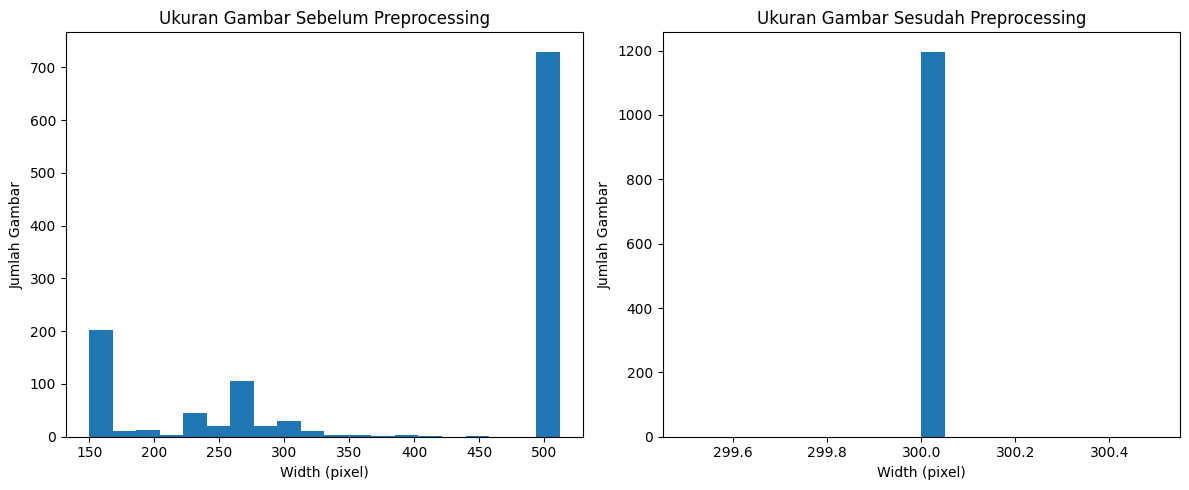

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(raw_sizes, bins=20)
ax[0].set_title("Ukuran Gambar Sebelum Preprocessing")
ax[0].set_xlabel("Width (pixel)")
ax[0].set_ylabel("Jumlah Gambar")

ax[1].hist(clean_sizes, bins=20)
ax[1].set_title("Ukuran Gambar Sesudah Preprocessing")
ax[1].set_xlabel("Width (pixel)")
ax[1].set_ylabel("Jumlah Gambar")

plt.tight_layout()
plt.show()

### **Visualisasi Boxplot**

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16824\3988189092.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


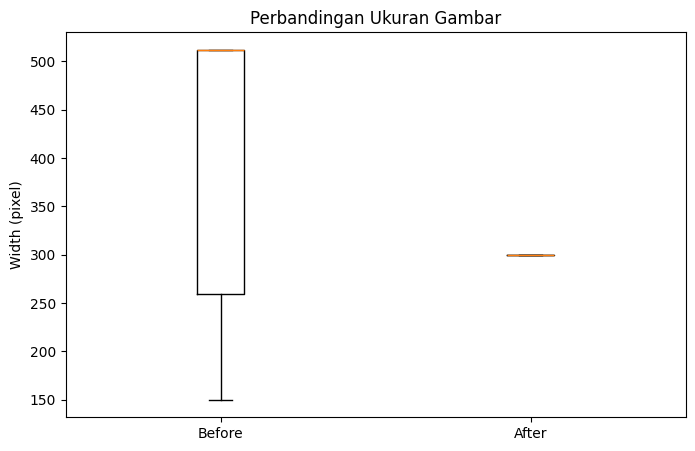

In [30]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [raw_sizes, clean_sizes],
    labels=["Before","After"])

plt.title("Perbandingan Ukuran Gambar")
plt.ylabel("Width (pixel)")
plt.show()

### **Membandingkan Standar Deviasi**

In [31]:
print("Standar Deviasi Raw :",np.std(raw_sizes))
print("Standar Deviasi Clean :",np.std(clean_sizes))

Standar Deviasi Raw : 150.25725070321528
Standar Deviasi Clean : 0.0


### **Uji Normalitas**

In [32]:
raw_normality = shapiro(raw_sizes)
clean_normality = shapiro(clean_sizes)

print("P-Value Raw :", raw_normality.pvalue)
print("P-Value Clean :", clean_normality.pvalue)

P-Value Raw : 6.034264721334891e-42
P-Value Clean : 1.0


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


### **Uji Homogenitas**

In [33]:
levene_test = levene(raw_sizes,clean_sizes)

print("P-Value Levene :",levene_test.pvalue)

P-Value Levene : 7.295381697267973e-138


### **Menetukan Hipotesis**

H0: Tidak terdapat perbedaan signifikan ukuran gambar sebelum dan sesudah preprocessing.

H1: Terdapat perbedaan signifikan ukuran gambar sebelum dan sesudah preprocessing.

### **Menentukan Uji Statistik**

In [34]:
if (raw_normality.pvalue > 0.05 and
clean_normality.pvalue > 0.05
):
    print("Gunakan Independent T-Test")
else:
    print("Gunakan Mann Whitney U Test")

Gunakan Mann Whitney U Test


In [35]:
u_stat, p_value = mannwhitneyu(
    raw_sizes,
    clean_sizes
)

print("U Statistic :", u_stat)

print("P Value :", p_value)

U Statistic : 915705.0
P Value : 5.36801559820968e-37


### **Keputusan Hipotesis**

In [36]:
alpha = 0.05

if p_value < alpha:
    print("Keputusan : Tolak H0")
    print("Terdapat perbedaan signifikan ukuran gambar sebelum dan sesudah preprocessing.")
else:
    print("Keputusan : Gagal Menolak H0")
    print("Tidak terdapat perbedaan signifikan ukuran gambar sebelum dan sesudah preprocessing.")

Keputusan : Tolak H0
Terdapat perbedaan signifikan ukuran gambar sebelum dan sesudah preprocessing.


## **KESIMPULAN**
Berdasarkan hasil Mann-Whitney U Test, diperoleh nilai U Statistic sebesar 915.705 dan p-value sebesar 5,37 × 10⁻³⁷, yang jauh lebih kecil dari tingkat signifikansi 0,05. Oleh karena itu, H₀ ditolak, sehingga dapat disimpulkan bahwa terdapat perbedaan yang signifikan antara ukuran gambar sebelum dan sesudah preprocessing. Hasil ini menunjukkan bahwa proses preprocessing yang dilakukan berhasil mengubah distribusi ukuran gambar menjadi lebih seragam dan konsisten dibandingkan kondisi awal.

***

## **2. A/B Testing Data Rekomendasi Bank Sampah**

Menguji apakah metode rekomendasi yang mempertimbangkan kapasitas bank sampah (Metode B) memberikan kualitas rekomendasi yang lebih baik dibandingkan metode rekomendasi berdasarkan jarak terdekat saja (Metode A).

In [37]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from sklearn.preprocessing import MinMaxScaler

In [38]:
data = pd.read_csv("D:/TUGAS KAMPUS SEMESTER 6/DICODING/Capstone/Capstone Code Data Scientist/data_bank_sampah_clean.csv")
data.head(2)

,Nama,Alamat,Kelurahan,Kecamatan,Kapasitas,Volume Masuk,Volume Dikelola,Volume Sampah Diolah,Volume Diangkut,Latitude,Longitude
0,TPS Pasar Asemrowo,Jl. Asemraya,Asemrowo,Asemrowo,8.0,8.0,8.0,8.0,8.0,-7.243424,112.703427
1,TPS Jayamix,Jl. Dupak Rukun,Asemrowo,Asemrowo,28.0,28.0,28.0,28.0,28.0,-7.243424,112.703427


### **PERUMUSAN HIPOTESIS**
H0 = Tidak terdapat perbedaan rata-rata Utility Score antara Metode A dan Metode B.

H1 = Rata-rata Utility Score Metode B lebih tinggi dibandingkan Metode A.

### **Hitung Sisa Kapasitas Bank Sampah**

In [39]:
data["Sisa_Kapasitas"] = (data["Kapasitas"] - data["Volume Masuk"])
data["Sisa_Kapasitas"] = data["Sisa_Kapasitas"].clip(lower=0)

### **Fungsi Haversine**

Tidak seperti perhitungan jarak biasa, rumus Haversine memperhitungkan kelengkungan bumi, sehingga memberikan hasil yang akurat saat mengukur jarak antar dua lokasi.

In [40]:
from math import radians
from math import sin
from math import cos
from math import sqrt
from math import atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat/2)**2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon/2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

### **Simulasi Beberapa Lokasi User (Misalnya 30 User)**

In [41]:
np.random.seed(42)

user_locations = []

for _ in range(30):

    lat = np.random.uniform(
       data["Latitude"].min(),
       data["Latitude"].max()
    )

    lon = np.random.uniform(
       data["Longitude"].min(),
       data["Longitude"].max()
    )

    user_locations.append((lat, lon))

### **Metode A (Rekomendasi berdasarkan jarak terdekat menggunakan koordinat latitude dan longitude)**

In [42]:
utility_A = []

for lat_user, lon_user in user_locations:

    temp = data.copy()

    temp["Jarak"] = temp.apply(
        lambda x: haversine(
            lat_user,
            lon_user,
            x["Latitude"],
            x["Longitude"]
        ),
        axis=1
    )

    rekom = temp.sort_values("Jarak").head(5)

    utility = (rekom["Sisa_Kapasitas"]/(rekom["Jarak"] + 0.1)).mean()
    utility_A.append(utility)

### **Metode B (Rekomendasi berdasarkan kombinasi antara jarak pengguna ke bank sampah & kapasitas tersisa bank sampah)**

Dengan mempertimbangkan kapasitas tersisa, sistem diharapkan dapat mengarahkan pengguna ke bank sampah yang masih mampu menerima sampah dalam jumlah lebih besar.

In [43]:
utility_B = []

for lat_user, lon_user in user_locations:

    temp = data.copy()

    temp["Jarak"] = temp.apply(
        lambda x: haversine(
            lat_user,
            lon_user,
            x["Latitude"],
            x["Longitude"]
        ),
        axis=1
    )

    scaler = MinMaxScaler()

    temp["Jarak_Norm"] = scaler.fit_transform(temp[["Jarak"]])

    temp["Kapasitas_Norm"] = scaler.fit_transform(temp[["Sisa_Kapasitas"]])

    temp["Score"] = (0.7 * (1 - temp["Jarak_Norm"])+0.3 * temp["Kapasitas_Norm"])

    rekom = temp.sort_values(
        "Score",
        ascending=False
    ).head(5)

    utility = (rekom["Sisa_Kapasitas"]/(rekom["Jarak"] + 0.1)).mean()
    utility_B.append(utility)

### **UJI STATISTIK**

In [44]:
t_stat, p_value = ttest_rel(
    utility_B,
    utility_A
)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : 8.375268082303561
P-Value : 3.1285939483055952e-09


In [45]:
print("Rata-rata Utility A:",
      np.mean(utility_A))

print("Rata-rata Utility B:",
      np.mean(utility_B))

Rata-rata Utility A: 1.5624818065230917
Rata-rata Utility B: 4.928836425384774


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Tolak H0")
    print("Metode B lebih baik secara signifikan")
else:
    print("Gagal menolak H0")
    print("Belum ada bukti bahwa Metode B lebih baik")

Tolak H0
Metode B lebih baik secara signifikan


## **KESIMPULAN**
Berdasarkan hasil A/B Testing menggunakan Paired T-Test, diperoleh nilai t-statistic sebesar 8,375 dan p-value sebesar 3,13 × 10⁻⁹, yang lebih kecil dari tingkat signifikansi 0,05. Oleh karena itu, H₀ ditolak, sehingga terdapat perbedaan yang signifikan antara Metode A (rekomendasi berdasarkan jarak terdekat) dan Metode B (rekomendasi berdasarkan kombinasi jarak dan kapasitas bank sampah). Selain itu, rata-rata Utility Score Metode B sebesar 4,93 lebih tinggi dibandingkan Metode A sebesar 1,56, menunjukkan bahwa metode yang mempertimbangkan kapasitas bank sampah mampu menghasilkan rekomendasi yang lebih optimal. Dengan demikian, Metode B dipilih sebagai pendekatan terbaik karena tidak hanya mempertimbangkan kedekatan lokasi, tetapi juga kemampuan bank sampah dalam menerima dan mengelola sampah dari pengguna.

***